In [2]:
from ase.io import read
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, InterpolatedUnivariateSpline
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from pathlib import Path

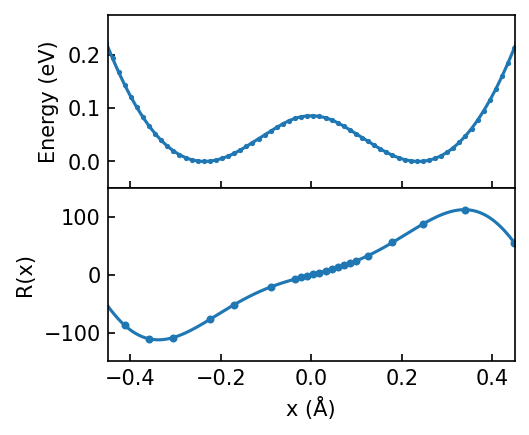

In [3]:
#Fig 1a

energies = np.loadtxt("Data/toten.dat")
energies -= np.min(energies)
x_saddle=0.23589477841686
x = np.linspace(-0.5, 0.9, len(energies))
x=x-x_saddle # to position the saddle point at x=zero
xfine = np.linspace(-0.5, 0.9, 1000)
xfine=xfine-x_saddle # to position the saddle point at x=zero
x_coarse = np.loadtxt("Data/x_1_a2.dat")
Rx_coarse = np.loadtxt("Data/Rx_coarse_1_a2.dat")
Rx_fine = np.loadtxt("Data/Rx_fine_1_a2.dat")
#Rx_coarse_1eV = np.loadtxt("Data/Rx_coarse_1eV.dat")
#Rx_fine_1eV = np.loadtxt("Data/Rx_fine_1eV.dat")
#Rx_coarse_15eV = np.loadtxt("Data/Rx_coarse_15eV.dat")
#Rx_fine_15eV = np.loadtxt("Data/Rx_fine_15eV.dat")
#Rx_coarse_25eV = np.loadtxt("Data/Rx_coarse_25eV.dat")
#Rx_fine_25eV = np.loadtxt("Data/Rx_fine_25eV.dat")

fig1a, (ax0,ax1) = plt.subplots(2, 1, figsize=(3.5, 3), dpi=150, facecolor='white', sharex=True)

ax0.plot(x, energies, 'C0o-', markersize=1.5)
ax0.set_xlim(-0.45, 0.45)
ax0.set_ylim(-0.05, 0.275)
ax0.set_ylabel('Energy (eV)')

ax1.scatter(x_coarse, Rx_coarse, s=8, color='C0')
ax1.plot(xfine, Rx_fine, label = r'$\omega$=2 eV')
# ax1.scatter(x_coarse, Rx_coarse_15eV, s=8, color='C1')
# ax1.plot(xfine, Rx_fine_15eV, color='C1', label = r'$\omega$=1.5 eV')
# ax1.scatter(x_coarse, Rx_coarse_25eV, s=8, color='C2')
# ax1.plot(xfine, Rx_fine_25eV, color='C2', label = r'$\omega$=2.5 eV')
ax1.set_xlim(-0.45, 0.45)
ax1.set_ylim(-150, 150)
ax1.set_xlabel("x (Å)")
ax1.set_ylabel("R(x)")

ax0.tick_params(direction='in', labelbottom=False)
ax1.tick_params(direction='in')

plt.subplots_adjust(hspace=0)
#plt.savefig('Fig1a-multiple_w.pdf', bbox_inches='tight')

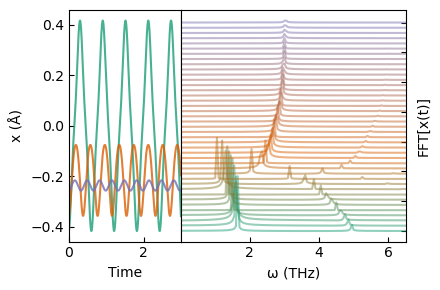

In [4]:
#Figure 1b

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Conversion factors
freq_in_thz = 6.3507799295888985  # converts ω to THz
t_in_ps = 1 / freq_in_thz

tspan = [0, 20 / t_in_ps]
tfine = np.linspace(*tspan, 20000)

# Load the data
sol_x = np.loadtxt('Data/sol_x_1b.dat')    # shape: (N_curves, N_time_points)
fft_x = np.loadtxt('Data/fft_x_1b.dat')    # shape: (N_curves, N_freq_points)
freq_x = np.loadtxt('Data/freq_x_1b.dat')  # shape: (N_freq_points,)

cmap = plt.get_cmap('Dark2')
base_colors = [cmap(i) for i in range(3)]

segment1_cmap = LinearSegmentedColormap.from_list('segment1', [base_colors[0], base_colors[1]], N=15)
segment2_cmap = LinearSegmentedColormap.from_list('segment2', [base_colors[1], base_colors[2]], N=26)
combined_colors = np.vstack((
    segment1_cmap(np.linspace(0, 1, 15)),
    segment2_cmap(np.linspace(0, 1, 26))
))

fig, (ax_time, ax_fft) = plt.subplots(
    1, 2,
    figsize=(4.5, 3),    
    facecolor='white',
    gridspec_kw={'width_ratios': [1, 2], 'wspace': 0.0}
)

# --------------------------------------------------
# Top panel: time‐series x(t) (height ratio = 1)
# --------------------------------------------------
for i in range(sol_x.shape[0]):
    ax_time.plot(
        tfine * t_in_ps,
        sol_x[i],
        color=base_colors[i],
        alpha=0.8
    )

ax_time.set_xlim(0, 3)
ax_time.set_ylabel("x (Å)")
ax_time.set_xlabel("Time")
ax_time.tick_params(direction='in')

# --------------------------------------------------
# Bottom panel: FFT ω vs amplitude (height ratio = 2)
# --------------------------------------------------
for i in range(fft_x.shape[0]):
    ax_fft.plot(
        freq_x,
        fft_x[i] + (i * 0.035),
        color=combined_colors[i],
        alpha=0.48
    )

ax_fft.set_xlabel("ω (THz)")
ax_fft.yaxis.set_label_position("right")
ax_fft.yaxis.tick_right()
ax_fft.set_ylabel("FFT[x(t)]")

ax_fft.set_xlim(0.01, 6.5)
ax_fft.tick_params(direction='in')
ax_fft.set_yticklabels([])  

plt.tight_layout()
plt.savefig('Fig1b_revised.pdf', bbox_inches='tight')

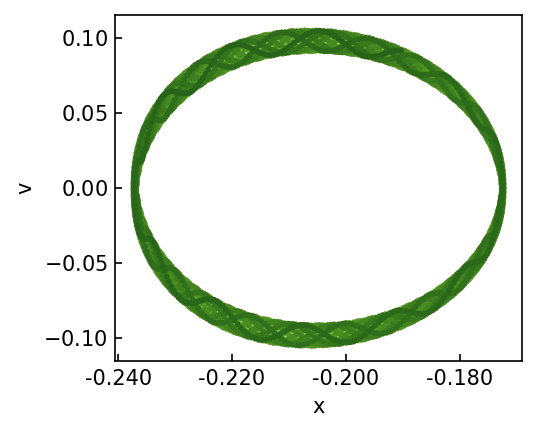

In [5]:
# Fig 1c-- inset

from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FormatStrFormatter
    
sol_x_sine = np.loadtxt('Data/sol_x_1c.dat')
sol_v_sine = np.loadtxt('Data/sol_v_1c.dat')

protocol = np.loadtxt('Data/protocol_1c.dat')
norm_protocol = np.loadtxt('Data/norm_protocol_1c.dat')

fig1c, ax3 = plt.subplots(figsize=(3.5, 3), dpi=150, facecolor='white')
norm1 = Normalize(vmin=np.min(tfine), vmax=np.max(tfine*t_in_ps))

ax3.scatter(sol_x_sine, sol_v_sine, c = tfine*t_in_ps, cmap='PiYG', edgecolor='none', norm=norm1, s=8)
ax3.set_xlabel('x')
ax3.set_ylabel('v')
ax3.tick_params(direction='in')
formatter = ScalarFormatter(useOffset=True, useMathText=True)
formatter.set_powerlimits((-2, 2))
ax3.yaxis.set_major_formatter(formatter)
ax3.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
#plt.savefig('Fig1c.pdf', bbox_inches='tight')

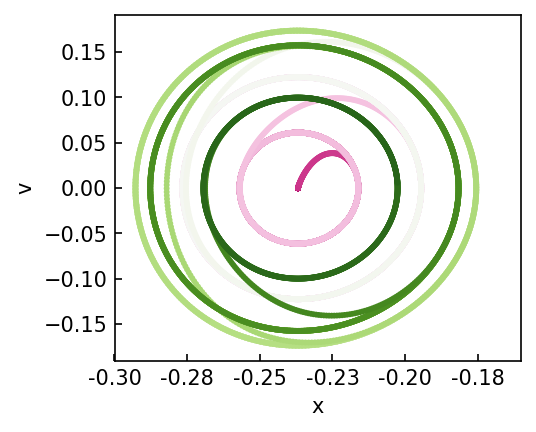

In [6]:
# Fig 1c--- inset

from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FormatStrFormatter
    
sol_x_pulse = np.loadtxt('Data/sol_x_1d.dat')
sol_v_pulse = np.loadtxt('Data/sol_v_1d.dat')

protocol2 = np.loadtxt('Data/protocol_1d.dat')
norm_protocol2 = np.loadtxt('Data/norm_protocol_1d.dat')

fig1d, ax4 = plt.subplots(figsize=(3.5, 3), dpi=150, facecolor='white')
norm1 = Normalize(vmin=np.min(tfine), vmax=np.max(tfine*t_in_ps))

ax4.scatter(sol_x_pulse, sol_v_pulse, c = tfine*t_in_ps, cmap='PiYG', edgecolor='none', norm=norm1, s=8)
ax4.set_xlabel('x')
ax4.set_ylabel('v')
ax4.tick_params(direction='in')
ax4.set_xlim(-0.30,-0.16)
ax4.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

#plt.savefig('Fig1d.pdf', bbox_inches='tight')


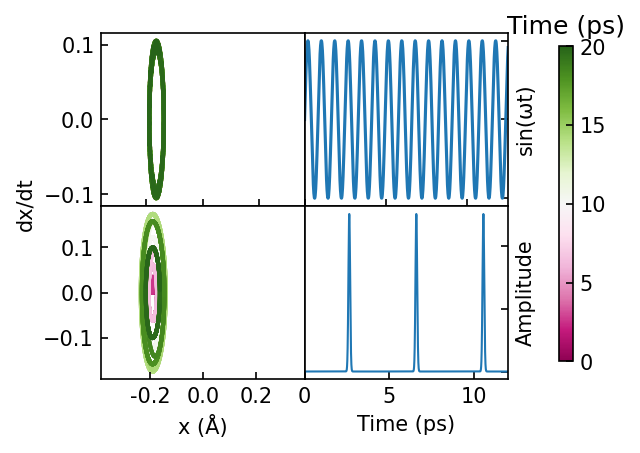

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter

# -----------------------------
# Load data
# -----------------------------
sol_x_sine = np.loadtxt('Data/sol_x_1c.dat')
sol_v_sine = np.loadtxt('Data/sol_v_1c.dat')

protocol = np.loadtxt('Data/protocol_1c.dat')
norm_protocol = np.loadtxt('Data/norm_protocol_1c.dat')

sol_x_pulse = np.loadtxt('Data/sol_x_1d.dat')
sol_v_pulse = np.loadtxt('Data/sol_v_1d.dat')

protocol2 = np.loadtxt('Data/protocol_1d.dat')
norm_protocol2 = np.loadtxt('Data/norm_protocol_1d.dat')

# -----------------------------
# Figure and axes
# -----------------------------
fig1cd, axs = plt.subplots(
    2, 2,
    figsize=(3.5, 3),
    dpi=150,
    facecolor='white'
)

(ax3, ax4, ax5, ax6) = axs.flatten()

# -----------------------------
# Common color normalization
# -----------------------------
norm1 = Normalize(
    vmin=np.min(tfine * t_in_ps),
    vmax=np.max(tfine * t_in_ps)
)

# -----------------------------
# Top-left: phase space (sine)
# -----------------------------
sc = ax3.scatter(
    sol_x_sine,
    sol_v_sine,
    c=tfine * t_in_ps,
    cmap='PiYG',
    norm=norm1,
    edgecolor='none',
    s=4
)

ax3.set_xlabel('x')
ax3.set_xlim(-0.45, 0.45)
ax3.tick_params(direction='in')
ax3.set_xticklabels([])

formatter = ScalarFormatter(useOffset=True, useMathText=True)
formatter.set_powerlimits((-2, 2))
ax3.yaxis.set_major_formatter(formatter)

# -----------------------------
# Top-right: protocol (sine)
# -----------------------------
ax4.plot(tfine, protocol)
ax4.set_xlabel('Time (ps)')
ax4.set_ylabel('sin(ωt)', labelpad=0.1)
ax4.set_xlim(0, 5)
ax4.tick_params(direction='in')
ax4.set_xticklabels([])
ax4.set_yticklabels([])
ax4.yaxis.set_label_position("right")
ax4.yaxis.tick_right()

# -----------------------------
# Bottom-left: phase space (pulse)
# -----------------------------
ax5.scatter(
    sol_x_pulse,
    sol_v_pulse,
    c=tfine * t_in_ps,
    cmap='PiYG',
    norm=norm1,
    edgecolor='none',
    s=4
)

ax5.set_xlabel('x (Å)')
ax5.set_xlim(-0.48, 0.48)
ax5.tick_params(direction='in')
ax5.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# -----------------------------
# Bottom-right: protocol (pulse)
# -----------------------------
ax6.plot(tfine * t_in_ps, protocol2, linewidth=1)
ax6.set_xlabel('Time (ps)')
ax6.set_ylabel('Amplitude', labelpad=0.1)
ax6.set_xlim(0, 12)
ax6.tick_params(direction='in')
ax6.set_yticklabels([])
ax6.yaxis.set_label_position("right")
ax6.yaxis.tick_right()

# -----------------------------
# Shared y-label
# -----------------------------
fig1cd.text(
    -0.02, 0.50,
    'dx/dt',
    ha='center',
    va='center',
    rotation='vertical'
)

# -----------------------------
# Single shared colorbar (fixed)
# -----------------------------
# Move further right to avoid overlap
cax = fig1cd.add_axes([0.998, 0.15, 0.025, 0.70])

cbar = fig1cd.colorbar(sc, cax=cax)
cbar.ax.tick_params(direction='in')

# Put label on TOP
cbar.ax.set_title('Time (ps)', pad=6)

# -----------------------------
# Layout
# -----------------------------
plt.subplots_adjust(wspace=0, hspace=0)

plt.savefig('Fig1cd.pdf', bbox_inches='tight')
plt.show()


bi_xmin = -0.2368685245784035
bi_phfreq_in_thz = 3.033783971322573


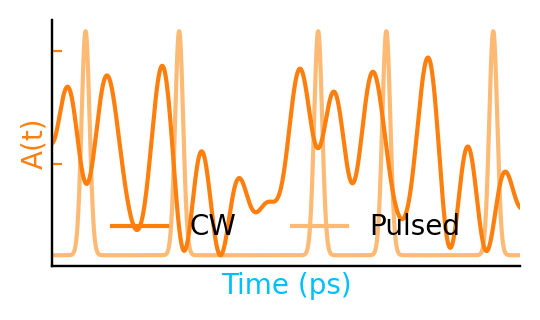

In [93]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import minimize

# ============================================================
# Common constants
# ============================================================
bi_mass = 208.9804
energy_in_ev = 0.004180159285619251
freq_in_thz = 6.3507799295888985
t_in_ps = 1 / freq_in_thz
x_saddle = 0.23589477841686

num_steps = 20000
total_time_ps = 20.0
t_sim = np.linspace(0, total_time_ps / t_in_ps, num_steps)
t_ps = t_sim * t_in_ps

# ============================================================
# Get Bi phonon frequency from PES
# ============================================================
energies = np.loadtxt(
    "/Users/sagrawal/Box/Research/ANL-Research/Carbon-data/Bi/single-point/analysis/toten.dat"
)

x_raw = np.linspace(-0.5, 0.9, len(energies))
x_shifted = x_raw - x_saddle

bi_yinterp = InterpolatedUnivariateSpline(
    x_shifted, energies / energy_in_ev, k=5
)

bi_xmin = minimize(
    bi_yinterp,
    [0.0],
    bounds=[(-0.1 - x_saddle, 0.1 - x_saddle)]
).x[0]

bi_phomega = np.sqrt(bi_yinterp(bi_xmin, nu=2) / bi_mass)
bi_phfreq_in_thz = bi_phomega * freq_in_thz / (2 * np.pi)

print("bi_xmin =", bi_xmin)
print("bi_phfreq_in_thz =", bi_phfreq_in_thz)

# ============================================================
# CW neural-network pulse
# ============================================================
class SimpleFNN(nn.Module):
    def __init__(self, bi_phfreq_in_thz):
        super().__init__()

        self.fc1 = nn.Linear(1, 10)
        self.fc2 = nn.Linear(10, 1)

        with torch.no_grad():
            self.fc1.weight = nn.Parameter(torch.tensor([
                [2*np.pi*(1.0 + bi_phfreq_in_thz/2)/freq_in_thz],
                [2*np.pi*(1.0 - bi_phfreq_in_thz/2)/freq_in_thz],
                [2*np.pi*(2.0 + bi_phfreq_in_thz/2)/freq_in_thz],
                [2*np.pi*(2.0 - bi_phfreq_in_thz/2)/freq_in_thz],
                [2*np.pi*(1.5 + bi_phfreq_in_thz/2)/freq_in_thz],
                [2*np.pi*(1.5 - bi_phfreq_in_thz/2)/freq_in_thz],
                [2*np.pi*(0.5 + bi_phfreq_in_thz/2)/freq_in_thz],
                [2*np.pi*(0.5 - bi_phfreq_in_thz/2)/freq_in_thz],
                [2*np.pi*(2.5 + bi_phfreq_in_thz/2)/freq_in_thz],
                [2*np.pi*(2.5 - bi_phfreq_in_thz/2)/freq_in_thz],
            ], dtype=torch.float32))

        nn.init.normal_(self.fc1.bias, mean=0, std=1)
        nn.init.normal_(self.fc2.weight, mean=0.8, std=1)
        nn.init.constant_(self.fc2.bias, 0)

    def forward(self, x):
        return self.fc2(torch.sin(self.fc1(x)))


def make_cw_pulse():
    net = SimpleFNN(bi_phfreq_in_thz)

    time_tensor = torch.tensor(t_sim.reshape(-1, 1), dtype=torch.float32)

    with torch.no_grad():
        A_t = net(time_tensor).numpy().squeeze()

    integral = simpson(y=A_t**2, x=t_sim)
    A_t_norm = A_t / np.sqrt(integral)

    return A_t_norm


# ============================================================
# Pulsed Gaussian train
# ============================================================
def make_pulse_train(centers_ps, sigma_ps=0.03):
    sigma = sigma_ps / t_in_ps
    pulse = np.zeros_like(t_sim)

    for c_ps in centers_ps:
        c_sim = c_ps / t_in_ps
        pulse += np.exp(-((t_sim - c_sim)**2) / (2 * sigma**2)) / (
            sigma * np.sqrt(2*np.pi)
        )

    # normalize like CW pulse
    integral = simpson(y=pulse**2, x=t_sim)
    pulse_norm = pulse / np.sqrt(integral)

    return pulse_norm


# ============================================================
# Generate signals
# ============================================================
A_cw = make_cw_pulse()

centers_ps = [0.25, 0.95, 1.99, 2.50, 3.30]
A_pulse = make_pulse_train(centers_ps, sigma_ps=0.03)

# ============================================================
# Single overlay plot
# ============================================================
# ============================================================
# Dual y-axis overlay plot for CW vs Pulsed A(t)
# ============================================================
fig, ax1 = plt.subplots(figsize=(2.8, 1.7), dpi=200, facecolor="white")

# Colors
time_color = "deepskyblue"
cw_color = "C1"
# pulse_color = "C8"
#cw_color     = "#D97706"   # deep true orange
pulse_color  = "#FDBA74"   # light warm orange

# time_color  = "#3B82F6"   # clean blue
# cw_color    = "#D97706"   # amber/orange
# pulse_color = "#7C3AED"   # violet

# ---------------- CW axis ----------------
ax1.plot(
    t_ps,
    A_cw,
    color=cw_color,
    lw=1.5,
    label="CW"
)

ax1.set_xlabel("Time (ps)", color=time_color, labelpad=2)
ax1.set_ylabel("A(t)", color=cw_color, labelpad=-2)

ax1.tick_params(axis="x", colors=time_color, direction="in")
ax1.tick_params(axis="y", colors=cw_color, direction="in")

ax1.set_xlim(0, 3.5)

# ---------------- Pulsed axis ----------------
ax2 = ax1.twinx()

ax2.plot(
    t_ps,
    A_pulse,
    color=pulse_color,
    lw=1.5,
    linestyle="-",
    label="Pulsed"
)

#ax2.set_ylabel("Pulsed $A(t)$", color=pulse_color)
ax2.tick_params(axis="y", colors=pulse_color, direction="in")
ax2.set_yticklabels([])
ax1.set_yticklabels([])

# ---------------- Combined legend ----------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.set_zorder(2)
ax2.set_zorder(1)
ax1.patch.set_visible(False)

leg = ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="lower center",
    frameon=False,
    ncol=2
)
leg.set_zorder(100)
# Remove top and right spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(axis='y', which='both', left=False, right=False, labelleft=False, labelright=False)
ax1.set_xticks([])
plt.tight_layout()

plt.savefig(
    "CW_vs_Pulsed_dual_axis_overlay.pdf",
    bbox_inches="tight"
)

plt.show()

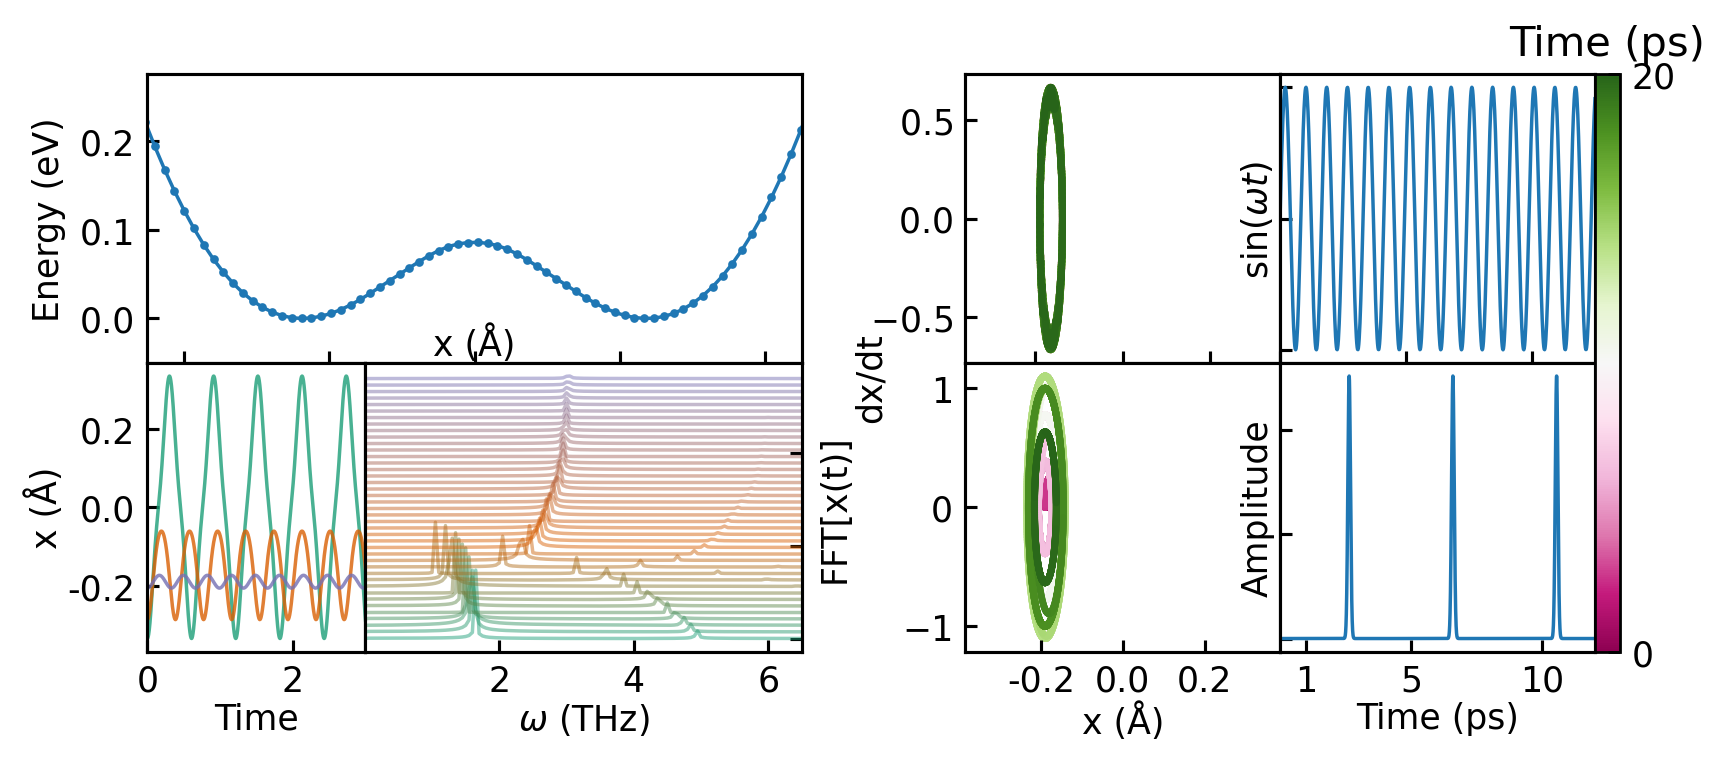

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter

# ============================================================
# Constants
# ============================================================
freq_in_thz = 6.3507799295888985
t_in_ps = 1 / freq_in_thz
x_saddle = 0.23589477841686

tspan = [0, 20 / t_in_ps]
tfine = np.linspace(*tspan, 20000)
t_ps = tfine * t_in_ps

# ============================================================
# Load Fig. 1a PES data
# ============================================================
energies = np.loadtxt("Data/toten.dat")
energies -= np.min(energies)

x = np.linspace(-0.5, 0.9, len(energies))
x = x - x_saddle

# ============================================================
# Load Fig. 1b data
# ============================================================
sol_x = np.loadtxt("Data/sol_x_1b.dat")
fft_x = np.loadtxt("Data/fft_x_1b.dat")
freq_x = np.loadtxt("Data/freq_x_1b.dat")

# ============================================================
# Load original Fig. 1c/d data
# ============================================================
sol_x_sine = np.loadtxt("Data/sol_x_1c.dat")
sol_v_sine = np.loadtxt("Data/sol_v_1c.dat")
sol_v_sine = sol_v_sine / t_in_ps
protocol = np.loadtxt("Data/protocol_1c.dat")
norm_protocol = np.loadtxt("Data/norm_protocol_1c.dat")

sol_x_pulse = np.loadtxt("Data/sol_x_1d.dat")
sol_v_pulse = np.loadtxt("Data/sol_v_1d.dat")
sol_v_pulse = sol_v_pulse / t_in_ps
protocol2 = np.loadtxt("Data/protocol_1d.dat")
norm_protocol2 = np.loadtxt("Data/norm_protocol_1d.dat")

# ============================================================
# Colors for Fig. 1b
# ============================================================
cmap = plt.get_cmap("Dark2")
base_colors = [cmap(i) for i in range(3)]

segment1_cmap = LinearSegmentedColormap.from_list(
    "segment1", [base_colors[0], base_colors[1]], N=15
)
segment2_cmap = LinearSegmentedColormap.from_list(
    "segment2", [base_colors[1], base_colors[2]], N=26
)

combined_colors = np.vstack((
    segment1_cmap(np.linspace(0, 1, 15)),
    segment2_cmap(np.linspace(0, 1, 26))
))

# ============================================================
# Main combined figure
# LEFT  = PES top + Fig. 1b bottom
# RIGHT = original Fig. 1c/d as second subplot
# ============================================================
fig = plt.figure(figsize=(7.6, 3.0), dpi=250, facecolor="white")

outer = fig.add_gridspec(
    1, 2,
    width_ratios=[1, 1],
    wspace=0.25
)

# ============================================================
# LEFT SUBPLOT: PES top + Fig. 1b bottom
# ============================================================
left = outer[0].subgridspec(
    2, 1,
    height_ratios=[1, 1],
    hspace=0.0
)

ax_pes = fig.add_subplot(left[0])

left_bottom = left[1].subgridspec(
    1, 2,
    width_ratios=[1, 2],
    wspace=0.0
)

ax_time = fig.add_subplot(left_bottom[0])
ax_fft = fig.add_subplot(left_bottom[1])

# -----------------------------
# Top: PES only from Fig. 1a
# -----------------------------
ax_pes.plot(x, energies, "C0o-", markersize=1.5, linewidth=1)

ax_pes.set_xlim(-0.45, 0.45)
ax_pes.set_ylim(-0.05, 0.275)

ax_pes.set_ylabel("Energy (eV)")
#ax_pes.set_xlabel("x (Å)", labelpad=0)

ax_pes.tick_params(direction="in", labelbottom=False)
ax_pes.text(
    0.5, 0.07,
    "x (Å)",
    transform=ax_pes.transAxes,
    ha="center",
    va="center"
)

# -----------------------------
# Bottom: Fig. 1b as bottom panel
# -----------------------------
for i in range(sol_x.shape[0]):
    ax_time.plot(
        t_ps,
        sol_x[i],
        color=base_colors[i % len(base_colors)],
        alpha=0.8,
        linewidth=1
    )

ax_time.set_xlim(0, 3)
ax_time.set_ylabel("x (Å)", labelpad=1)
ax_time.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax_time.set_xlabel("Time", labelpad=1)
ax_time.tick_params(direction="in")

for i in range(fft_x.shape[0]):
    ax_fft.plot(
        freq_x,
        fft_x[i] + (i * 0.035),
        color=combined_colors[i % len(combined_colors)],
        alpha=0.48,
        linewidth=1
    )

ax_fft.set_xlabel(r"$\omega$ (THz)", labelpad=1)
ax_fft.yaxis.set_label_position("right")
ax_fft.yaxis.tick_right()
ax_fft.set_ylabel("FFT[x(t)]", labelpad=1)

ax_fft.set_xlim(0.01, 6.5)
ax_fft.tick_params(direction="in")
ax_fft.set_yticklabels([])

# ============================================================
# RIGHT SUBPLOT: ORIGINAL Fig. 1c/d structure
# 2x2 panels + one shared colorbar
# ============================================================
right = outer[1].subgridspec(
    2, 3,
    width_ratios=[1, 1, 0.08],
    height_ratios=[1, 1],
    wspace=0.0,
    hspace=0.0
)

ax3 = fig.add_subplot(right[0, 0])   # top-left phase space sine
ax4 = fig.add_subplot(right[0, 1])   # top-right protocol sine
ax5 = fig.add_subplot(right[1, 0])   # bottom-left phase space pulse
ax6 = fig.add_subplot(right[1, 1])   # bottom-right protocol pulse
cax = fig.add_subplot(right[:, 2])   # shared colorbar, outside 2x2

norm1 = Normalize(
    vmin=np.min(t_ps),
    vmax=np.max(t_ps)
)

# -----------------------------
# Top-left: phase space sine
# -----------------------------
sc = ax3.scatter(
    sol_x_sine,
    sol_v_sine,
    c=t_ps,
    cmap="PiYG",
    norm=norm1,
    edgecolor="none",
    s=4
)

ax3.set_xlabel("x", labelpad=1)
ax3.set_xlim(-0.45, 0.45)
ax3.tick_params(direction="in")
ax3.set_xticklabels([])

formatter = ScalarFormatter(useOffset=True, useMathText=True)
formatter.set_powerlimits((-2, 2))
ax3.yaxis.set_major_formatter(formatter)

# -----------------------------
# Top-right: protocol sine
# -----------------------------
ax4.plot(tfine, protocol, linewidth=1)
ax4.set_xlabel("Time (ps)", labelpad=1)
ax4.set_ylabel(r"sin($\omega t$)", labelpad=-2)
ax4.set_xlim(0, 5)
ax4.tick_params(direction="in")
ax4.set_xticklabels([])
ax4.set_yticklabels([])
ax4.yaxis.set_label_position("left")
ax4.yaxis.tick_left()

# -----------------------------
# Bottom-left: phase space pulse
# -----------------------------
ax5.scatter(
    sol_x_pulse,
    sol_v_pulse,
    c=t_ps,
    cmap="PiYG",
    norm=norm1,
    edgecolor="none",
    s=4
)

ax5.set_xlabel("x (Å)", labelpad=1)
ax5.set_xlim(-0.48, 0.48)
ax5.tick_params(direction="in")
ax5.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))

# -----------------------------
# Bottom-right: protocol pulse
# -----------------------------
ax6.plot(t_ps, protocol2, linewidth=1)
ax6.set_xlabel("Time (ps)", labelpad=1)
ax6.set_ylabel("Amplitude", labelpad=-2)
ax6.set_xlim(0, 12)
ax6.set_xticks([1, 5, 10])
ax6.set_xticklabels(["1", "5", "10"])
ax6.tick_params(direction="in")
ax6.set_yticklabels([])
ax6.yaxis.set_label_position("left")
#ax6.yaxis.tick_left()

# -----------------------------
# Shared y-label for Fig. 1c/d
# -----------------------------
ax3.text(
    -0.3, -0.05,
    "dx/dt",
    transform=ax3.transAxes,
    ha="center",
    va="center",
    rotation="vertical" 
)

# -----------------------------
# Shared colorbar for Fig. 1c/d
# -----------------------------
cbar = fig.colorbar(sc, cax=cax)
cbar.set_ticks([0, 20])
cbar.set_ticklabels(["0", "20"])
cbar.ax.tick_params(direction="in")
cbar.ax.set_title("Time (ps)", pad=5.5)

# ============================================================
# Styling
# ============================================================
for ax in [ax_pes, ax_time, ax_fft, ax3, ax4, ax5, ax6]:
    ax.tick_params(direction="in", width=0.9)
    for spine in ax.spines.values():
        spine.set_linewidth(0.9)

plt.savefig("Fig_1_no_Rx.pdf", bbox_inches="tight")
plt.show()